# Research Appendix: Robustness and Reconstruction

## Purpose and fixed protocol

Explain how measurement and implementation choices affect the result without
searching for a winning strategy. This appendix does not replace the primary
NSA/EWM specification. All variants are reported, with no ranking or selection.

Primary data remain the immutable 2026-09-28 snapshot. The separate supplementary
2026-10-01 snapshot contains official public GS10/DGS10 data solely for US yield
sampling diagnostics. Both are current vintages, not historical real-time inputs.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.ticker import PercentFormatter
from inflation_base_effects.data import REPO_ROOT, compute_base_effect, load_cpi, load_yields
from inflation_base_effects.portfolio import compute_bond_returns
from inflation_base_effects.research import (
    benchmark_regression,
    comparison_table,
    constraint_summary,
    coverage,
    leave_one_out,
    legacy_evaluation_comparison,
    mechanism_regression,
    performance_summary,
    plot_mechanical_effect,
    portfolio_attribution,
    realized_turnover,
    run_experiment,
    sensitivity_experiments,
)

pd.options.display.float_format = "{:.4f}".format
plt.style.use("seaborn-v0_8-whitegrid")
FIGURES = Path(REPO_ROOT) / "docs" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)

import hashlib
import json
from inflation_base_effects.portfolio import mod_duration

headline_nsa = load_cpi()
yields_monthly = load_yields()
baseline = run_experiment(headline_nsa, yields_monthly)
display(
    performance_summary(baseline.returns, realized_turnover(baseline.holdings)).to_frame("primary")
)

,primary
N,400.0000
ann_return,-0.0008
ann_vol,0.0275
return_to_vol,-0.0276
NW t-stat,-0.1756
NW p-value,0.8606
CI 95% lower,-0.0092
CI 95% upper,0.0077
NW maxlags,5.0000
max_additive_drawdown,-0.1822


## 1. What is recoverable from the scans?

The recovered conclusion reports approximately -0.60% annual return, 3.54%
annual volatility, return/volatility -0.17, and HAC t=-1.15 (p=0.252).
The preceding public repository reports approximately -0.08%, 2.75%, -0.03,
and t=-0.18 (p=0.854). Those are distinct implementations, not rounding noise.

Evidence: the conclusion in `scans/02_signal_and_backtest.pdf` and the prior
public README at commit `b8a2f93`. Scans are retained locally as recovery evidence
and intentionally excluded from publication because they may contain credentials.

The **original downloaded vintage and complete execution state are unavailable**.
Consequently the following is a controlled sensitivity bridge, not a claim to
exactly reproduce the scanned numbers or to allocate every basis point between
causes. Changes may interact, so their isolated effects do not necessarily sum.

## 2. Verified correction: continuous duration at low and negative yields

The previous shortcut assigned duration 10 whenever yield was at or below 0.1%,
including negative yields and missing observations. It introduced a discontinuity
at that threshold and suppressed variation during negative-yield periods.

Use the same par-bond formula continuously:

$$D(y)=\frac{1-(1+y/2)^{-2T}}{y},\qquad D(0)=T.$$

`log1p`/`expm1` avoid cancellation near zero, and missing yields remain missing.
Negative-coupon par bonds are an algebraic proxy, not a claim about available
instruments. Finite cash-flow tests independently verify the positive-yield formula.

In [2]:
yield_grid = np.array([-1, -0.5, -0.001, 0, 0.001, 0.099999, 0.1, 0.100001, 1, 5])
duration_review = pd.DataFrame(
    {
        "yield_pct": yield_grid,
        "corrected_duration": [mod_duration(y) for y in yield_grid],
        "previous_duration": [
            10 if y <= 0.1 else (1 - (1 + y / 200) ** -20) / (y / 100) for y in yield_grid
        ],
    }
).set_index("yield_pct")
with pd.option_context("display.float_format", "{:.6f}".format):
    display(duration_review)
legacy = run_experiment(headline_nsa, yields_monthly, legacy_duration=True)
duration_bridge = comparison_table(
    {
        "Prior public duration rule": legacy.returns,
        "Continuous duration correction": baseline.returns,
    }
)
display(duration_bridge)
display(
    (
        10000
        * (
            duration_bridge.loc["Continuous duration correction", ["ann_return", "ann_vol"]].astype(
                float
            )
            - duration_bridge.loc["Prior public duration rule", ["ann_return", "ann_vol"]].astype(
                float
            )
        )
    ).to_frame("correction minus previous (basis points)")
)

,corrected_duration,previous_duration
yield_pct,,
-1.000000,10.544817,10.000000
-0.500000,10.267383,10.000000
-0.001000,10.000525,10.000000
0.000000,10.000000,10.000000
0.001000,9.999475,10.000000
0.099999,9.947692,10.000000
0.100000,9.947692,10.000000
0.100001,9.947691,9.947691
1.000000,9.493710,9.493710


,N,ann_return,ann_vol,return_to_vol,NW t-stat,NW p-value,CI 95% lower,CI 95% upper,NW maxlags,max_additive_drawdown,mean_monthly_turnover,start,end
Prior public duration rule,400.0000,-0.0008,0.0275,-0.0289,-0.1846,0.8535,-0.0092,0.0077,5.0000,-0.1823,NaN,1991-09,2024-12
Continuous duration correction,400.0000,-0.0008,0.0275,-0.0276,-0.1756,0.8606,-0.0092,0.0077,5.0000,-0.1822,NaN,1991-09,2024-12


,correction minus previous (basis points)
ann_return,0.3792
ann_vol,0.1334


## 3. Timing, missing contributions, and sample selection

Hold the current portfolio fixed to isolate evaluation choices. The zero-filled
case can include a first month with no prior position and missing asset data.
The contemporaneous-holdings row is **noncausal** and is shown only as a warning
about accounting choices; it is not asserted to be the source of the historical
gap and is never promoted to an investable strategy.

A separate endpoint correction moves implementation-delay calendar labels instead
of shifting inside a finite table. This preserves the last eligible print when a
reduced universe ends earlier than the available returns. It does not change the
four-country primary history, but avoids dropping the final month of the non-US
leave-one-out experiment. Regression tests protect this boundary condition.

Report full available and common-date results: differences from merely admitting
extra observations should not be confused with a change on identical dates.

In [3]:
evaluation_cases = legacy_evaluation_comparison(baseline.holdings, yields_monthly)
display(comparison_table(evaluation_cases, common=False))
display(comparison_table(evaluation_cases, common=True))
sample_cases = {
    "Full available primary": baseline.returns,
    "Fixed 2010 onward": baseline.returns.loc["2010-01-01":],
}
display(comparison_table(sample_cases, common=False))

,N,ann_return,ann_vol,return_to_vol,NW t-stat,NW p-value,CI 95% lower,CI 95% upper,NW maxlags,max_additive_drawdown,mean_monthly_turnover,start,end
"Prior holdings, complete cases",400.0000,-0.0008,0.0275,-0.0276,-0.1756,0.8606,-0.0092,0.0077,5.0000,-0.1822,NaN,1991-09,2024-12
"Prior holdings, missing contributions zero",401.0000,-0.0008,0.0275,-0.0275,-0.1757,0.8606,-0.0092,0.0077,5.0000,-0.1822,NaN,1991-08,2024-12
Contemporaneous holdings (NONCAUSAL),401.0000,0.0065,0.0265,0.2468,1.3229,0.1859,-0.0032,0.0163,5.0000,-0.1585,NaN,1991-08,2024-12


,N,ann_return,ann_vol,return_to_vol,NW t-stat,NW p-value,CI 95% lower,CI 95% upper,NW maxlags,max_additive_drawdown,mean_monthly_turnover,start,end
"Prior holdings, complete cases",400.0000,-0.0008,0.0275,-0.0276,-0.1756,0.8606,-0.0092,0.0077,5.0000,-0.1822,NaN,1991-09,2024-12
"Prior holdings, missing contributions zero",400.0000,-0.0008,0.0275,-0.0276,-0.1756,0.8606,-0.0092,0.0077,5.0000,-0.1822,NaN,1991-09,2024-12
Contemporaneous holdings (NONCAUSAL),400.0000,0.0063,0.0265,0.2388,1.2760,0.2020,-0.0034,0.0161,5.0000,-0.1585,NaN,1991-09,2024-12


,N,ann_return,ann_vol,return_to_vol,NW t-stat,NW p-value,CI 95% lower,CI 95% upper,NW maxlags,max_additive_drawdown,mean_monthly_turnover,start,end
Full available primary,400.0000,-0.0008,0.0275,-0.0276,-0.1756,0.8606,-0.0092,0.0077,5.0000,-0.1822,NaN,1991-09,2024-12
Fixed 2010 onward,180.0000,0.0020,0.0270,0.0756,0.2985,0.7653,-0.0113,0.0154,4.0000,-0.0810,NaN,2010-01,2024-12


## 4. US yield sampling: monthly averages versus month-end

GS10 averages business-day yields. DGS10 supplies daily yields; take the last
available business-day observation of each completed month. Do not interpolate
holidays. Both are yield observations, not total-return indices.

Compare (a) a US long-only proxy and (b) the US contribution of the **same primary
holdings** on common dates. Then replace only the US series in the four-country
optimizer, keeping the other data and rules fixed. The latter is a deliberately
mixed-sampling diagnostic, not an improved primary model.

Sources: [GS10](https://fred.stlouisfed.org/series/GS10) and
[DGS10](https://fred.stlouisfed.org/series/DGS10). Retrieval URLs, time, and SHA-256
checksums accompany the supplementary snapshot. Differences from the baseline
GS10 vintage are inspected before attributing changes to sampling.

In [4]:
supplement = Path(REPO_ROOT) / "data/supplementary/2026-10-01"
manifest = json.loads((supplement / "manifest.json").read_text())
for name, expected in manifest["sha256"].items():
    assert hashlib.sha256((supplement / name).read_bytes()).hexdigest() == expected
average = pd.read_csv(supplement / "GS10.csv", index_col=0, parse_dates=True).iloc[:, 0]
daily = pd.read_csv(supplement / "DGS10.csv", index_col=0, parse_dates=True).iloc[:, 0]
month_end = daily.resample("MS").last()
# Only months completed before the supplementary snapshot date are eligible.
completed = pd.Timestamp("2026-10-01")
month_end = month_end.loc[month_end.index < completed]
average = average.loc[average.index < completed]
us_column = "B_USA_BD"
vintage_check = pd.concat(
    {"baseline": yields_monthly[us_column], "supplement": average}, axis=1
).dropna()
display(
    pd.Series(
        {
            "overlap_months": len(vintage_check),
            "max_GS10_difference_pp": (vintage_check.baseline - vintage_check.supplement)
            .abs()
            .max(),
        }
    )
)
average_ret, _ = compute_bond_returns(average.to_frame(us_column))
end_ret, _ = compute_bond_returns(month_end.to_frame(us_column))
us_returns = pd.concat(
    {"Monthly-average proxy": average_ret[us_column], "Month-end proxy": end_ret[us_column]}, axis=1
).dropna()
us_returns = us_returns.loc[baseline.returns.index.min() : baseline.returns.index.max()]
display(comparison_table(dict(us_returns.items())))
display(us_returns.corr())
prior_us_h = baseline.holdings[us_column].shift(1).reindex(us_returns.index)
display(comparison_table({name: series * prior_us_h for name, series in us_returns.items()}))
mixed_yields = yields_monthly.copy()
mixed_yields[us_column] = month_end.reindex(mixed_yields.index)
mixed_experiment = run_experiment(headline_nsa, mixed_yields)
display(
    comparison_table(
        {
            "Primary monthly averages": baseline.returns,
            "US month-end only (mixed diagnostic)": mixed_experiment.returns,
        }
    )
)

overlap_months           440.0000
max_GS10_difference_pp     0.0000
dtype: float64

,N,ann_return,ann_vol,return_to_vol,NW t-stat,NW p-value,CI 95% lower,CI 95% upper,NW maxlags,max_additive_drawdown,mean_monthly_turnover,start,end
Monthly-average proxy,400.0000,0.0472,0.0631,0.7477,3.5831,0.0003,0.0214,0.0730,5.0000,-0.2933,NaN,1991-09,2024-12
Month-end proxy,400.0000,0.0459,0.0754,0.6084,3.3827,0.0007,0.0193,0.0725,5.0000,-0.3075,NaN,1991-09,2024-12


,Monthly-average proxy,Month-end proxy
Monthly-average proxy,1.0000,0.7220
Month-end proxy,0.7220,1.0000


,N,ann_return,ann_vol,return_to_vol,NW t-stat,NW p-value,CI 95% lower,CI 95% upper,NW maxlags,max_additive_drawdown,mean_monthly_turnover,start,end
Monthly-average proxy,400.0000,-0.0066,0.0314,-0.2106,-1.1627,0.2450,-0.0177,0.0045,5.0000,-0.2955,NaN,1991-09,2024-12
Month-end proxy,400.0000,-0.0115,0.0371,-0.3093,-1.7910,0.0733,-0.0240,0.0011,5.0000,-0.4577,NaN,1991-09,2024-12


,N,ann_return,ann_vol,return_to_vol,NW t-stat,NW p-value,CI 95% lower,CI 95% upper,NW maxlags,max_additive_drawdown,mean_monthly_turnover,start,end
Primary monthly averages,400.0000,-0.0008,0.0275,-0.0276,-0.1756,0.8606,-0.0092,0.0077,5.0000,-0.1822,NaN,1991-09,2024-12
US month-end only (mixed diagnostic),400.0000,-0.0045,0.0358,-0.1270,-0.8472,0.3969,-0.0151,0.0060,5.0000,-0.3015,NaN,1991-09,2024-12


These comparisons do not recover the original DGS10 vintage or make the other
countries' monthly-average inputs executable. No single diagnostic is an exact
explanation of the scanned/public result difference. Full historical vintage
reconstruction is deferred; frozen contemporary data solve reproducibility,
not historical information availability.

## 5. Declared one-at-a-time robustness grid

| Family | Values | Fixed primary default |
|---|---|---|
| EWM score half-life | 3, 6, 12 months | 6 |
| Assumed IC | 0.01, 0.025, 0.05, 0.10 | 0.05 |
| Implementation delay | 1, 2, 3 months | 1 |
| Covariance half-lives | (6,18), (12,36), (24,72) | (12,36) |

Vary exactly one control at a time, retaining the 0.7/0.3 covariance blend and
all constraints. Baseline runs are reused, not recomputed with different rules.
Use common dates **within each family**; families may have different warm-ups.
Every variant is disclosed, and all p-values are nominal, not multiplicity-adjusted.
The grid is descriptive sensitivity analysis on already-viewed data, not a model
selection procedure or a new independent discovery sample.

In [5]:
families = sensitivity_experiments(headline_nsa, yields_monthly, baseline=baseline)
sensitivity_tables = {}
for family, variants in families.items():
    sensitivity_tables[family] = comparison_table(
        {label: experiment.returns for label, experiment in variants.items()},
        {label: experiment.holdings for label, experiment in variants.items()},
    )
sensitivity = pd.concat(sensitivity_tables, names=["family", "value"])
display(sensitivity)
display(
    pd.concat(
        {
            family: pd.DataFrame(
                {label: constraint_summary(exp.diagnostics) for label, exp in variants.items()}
            ).T
            for family, variants in families.items()
        },
        names=["family", "value"],
    )
)

N ann_return ann_vol return_to_vol  \
family               value                                                
Smoothing            3        394.0000    -0.0006  0.0265       -0.0223   
                     6        394.0000    -0.0010  0.0273       -0.0350   
                     12       394.0000    -0.0013  0.0272       -0.0466   
Assumed IC           0.01     400.0000    -0.0016  0.0243       -0.0665   
                     0.025    400.0000    -0.0009  0.0263       -0.0360   
                     0.05     400.0000    -0.0008  0.0275       -0.0276   
                     0.1      400.0000    -0.0004  0.0280       -0.0160   
Implementation delay 1        398.0000    -0.0007  0.0276       -0.0244   
                     2        398.0000     0.0035  0.0276        0.1282   
                     3        398.0000    -0.0029  0.0270       -0.1087   
Covariance           (6, 18)  395.0000    -0.0013  0.0273       -0.0466   
                     (12, 36) 395.0000    -0.0002  0.0276       -0.0063   
                     (24, 72) 395.0000     0.0000  0.0277        0.0005   

                              NW t-stat NW p-value CI 95% lower CI 95% upper  \
family               value                                                     
Smoothing            3          -0.1367     0.8913      -0.0091       0.0079   
                     6          -0.2217     0.8246      -0.0094       0.0075   
                     12         -0.2893     0.7724      -0.0099       0.0073   
Assumed IC           0.01       -0.4273     0.6692      -0.0090       0.0058   
                     0.025      -0.2287     0.8191      -0.0091       0.0072   
                     0.05       -0.1756     0.8606      -0.0092       0.0077   
                     0.1        -0.1031     0.9179      -0.0089       0.0081   
Implementation delay 1          -0.1554     0.8765      -0.0092       0.0078   
                     2           0.7798     0.4355      -0.0054       0.0125   
                     3          -0.5834     0.5597      -0.0128       0.0069   
Covariance           (6, 18)    -0.2835     0.7768      -0.0101       0.0075   
                     (12, 36)   -0.0395     0.9685      -0.0088       0.0085   
                     (24, 72)    0.0031     0.9975      -0.0086       0.0087   

                              NW maxlags max_additive_drawdown  \
family               value                                       
Smoothing            3            5.0000               -0.2094   
                     6            5.0000               -0.1822   
                     12           5.0000               -0.1668   
Assumed IC           0.01         5.0000               -0.1427   
                     0.025        5.0000               -0.1613   
                     0.05         5.0000               -0.1822   
                     0.1          5.0000               -0.1777   
Implementation delay 1            5.0000               -0.1822   
                     2            5.0000               -0.1025   
                     3            5.0000               -0.1873   
Covariance           (6, 18)      5.0000               -0.2133   
                     (12, 36)     5.0000               -0.1822   
                     (24, 72)     5.0000               -0.1809   

                              mean_monthly_turnover    start      end  
family               value                                             
Smoothing            3                       2.0258  1992-03  2024-12  
                     6                       1.9824  1992-03  2024-12  
                     12                      1.9848  1992-03  2024-12  
Assumed IC           0.01                    1.9309  1991-09  2024-12  
                     0.025                   1.9571  1991-09  2024-12  
                     0.05                    1.9805  1991-09  2024-12  
                     0.1                     1.9822  1991-09  2024-12  
Implementation delay 1                       1.9806  1991-11  2024-12  

months  failed  max_duration_residual  \
family               value                                              
Smoothing            3        404.0000  0.0000                 0.0000   
                     6        401.0000  0.0000                 0.0000   
                     12       395.0000  0.0000                 0.0000   
Assumed IC           0.01     401.0000  0.0000                 0.0000   
                     0.025    401.0000  0.0000                 0.0000   
                     0.05     401.0000  0.0000                 0.0000   
                     0.1      401.0000  0.0000                 0.0000   
Implementation delay 1        401.0000  0.0000                 0.0000   
                     2        401.0000  0.0000                 0.0000   
                     3        401.0000  0.0000                 0.0000   
Covariance           (6, 18)  401.0000  0.0000                 0.0000   
                     (12, 36) 401.0000  0.0000                 0.0000   
                     (24, 72) 396.0000  0.0000                 0.0000   

                               max_gross  max_position  max_forecast_vol  \
family               value                                                 
Smoothing            3            2.0000        0.5000            0.0552   
                     6            2.0000        0.5000            0.0554   
                     12           2.0000        0.5000            0.0554   
Assumed IC           0.01         2.0000        0.5000            0.0467   
                     0.025        2.0000        0.5000            0.0483   
                     0.05         2.0000        0.5000            0.0554   
                     0.1          2.0000        0.5000            0.0554   
Implementation delay 1            2.0000        0.5000            0.0554   
                     2            1.9998        0.5000            0.0541   
                     3            2.0000        0.5000            0.0530   
Covariance           (6, 18)      2.0000        0.5000            0.0637   
                     (12, 36)     2.0000        0.5000            0.0554   
                     (24, 72)     2.0000        0.5000            0.0435   

                               position_binding_pct  gross_binding_pct  \
family               value                                               
Smoothing            3                      99.7525             2.2277   
                     6                      99.7506             2.2444   
                     12                    100.0000             2.2785   
Assumed IC           0.01                   97.7556             0.9975   
                     0.025                  99.5012             1.9950   
                     0.05                   99.7506             2.2444   
                     0.1                   100.0000             2.7431   
Implementation delay 1                      99.7506             2.2444   
                     2                     100.0000             3.2419   
                     3                     100.0000             2.4938   
Covariance           (6, 18)               100.0000             2.2444   
                     (12, 36)               99.7506             2.2444   
                     (24, 72)              100.0000             2.5253   

                               vol_binding_pct  
family               value                      
Smoothing            3                  0.0000  
                     6                  0.0000  
                     12                 0.0000  
Assumed IC           0.01               0.0000  
                     0.025              0.0000  
                     0.05               0.0000  
                     0.1                0.0000  
Implementation delay 1                  0.0000  
                     2                  0.0000  
                     3                  0.0000  
Covariance           (6, 18)            0.0000  
                     (12, 36)           0.0000 

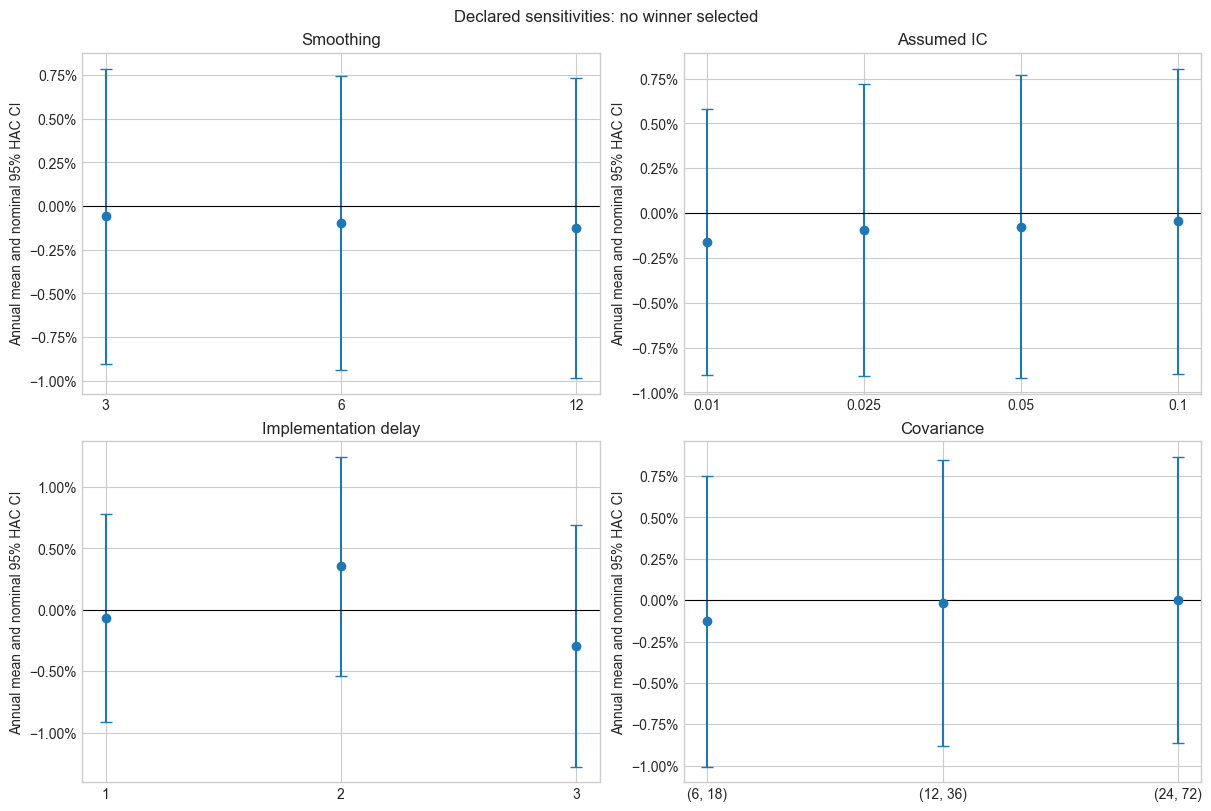

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
for ax, (family, table) in zip(axes.flat, sensitivity_tables.items(), strict=True):
    mean = table.ann_return.astype(float)
    lower = table["CI 95% lower"].astype(float)
    upper = table["CI 95% upper"].astype(float)
    ax.errorbar(range(len(table)), mean, yerr=[mean - lower, upper - mean], fmt="o", capsize=4)
    ax.set_xticks(range(len(table)), table.index)
    ax.axhline(0, color="black", lw=0.8)
    ax.yaxis.set_major_formatter(PercentFormatter(1))
    ax.set(title=family, ylabel="Annual mean and nominal 95% HAC CI")
fig.suptitle("Declared sensitivities: no winner selected")
fig.savefig(FIGURES / "robustness_intervals.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. Inference sensitivity, not strategy selection

Hold returns fixed and vary only Newey-West lag length. The automatic rule is
the primary inference convention. Wide intervals should be read in economic
units: they may admit both losses and gains large enough to matter, even when a
p-value is large. Failure to reject zero is not evidence of equivalence to zero.

In [7]:
display(
    pd.DataFrame(
        {str(lag): performance_summary(baseline.returns, maxlags=lag) for lag in [None, 3, 6, 12]}
    ).T.rename(index={"None": "automatic"})
)
primary_inference = performance_summary(baseline.returns)
print(
    f"Primary annual mean: {primary_inference['ann_return']:.2%}; "
    f"95% HAC interval: [{primary_inference['CI 95% lower']:.2%}, "
    f"{primary_inference['CI 95% upper']:.2%}]."
)

,N,ann_return,ann_vol,return_to_vol,NW t-stat,NW p-value,CI 95% lower,CI 95% upper,NW maxlags,max_additive_drawdown,mean_monthly_turnover,start,end
automatic,400.0000,-0.0008,0.0275,-0.0276,-0.1756,0.8606,-0.0092,0.0077,5.0000,-0.1822,NaN,1991-09,2024-12
3,400.0000,-0.0008,0.0275,-0.0276,-0.1661,0.8681,-0.0097,0.0082,3.0000,-0.1822,NaN,1991-09,2024-12
6,400.0000,-0.0008,0.0275,-0.0276,-0.1792,0.8578,-0.0090,0.0075,6.0000,-0.1822,NaN,1991-09,2024-12
12,400.0000,-0.0008,0.0275,-0.0276,-0.1924,0.8474,-0.0085,0.0070,12.0000,-0.1822,NaN,1991-09,2024-12


Primary annual mean: -0.08%; 95% HAC interval: [-0.92%, 0.77%].


## 7. What the reconstruction can and cannot conclude

The continuous-duration bridge isolates a verified code correction. The sampling
comparison isolates a recoverable measurement choice, while evaluation and sample
tables show how accounting and date coverage change reported statistics. They do
not reconstruct an unavailable original vintage or establish that each change
caused a known portion of the historical result gap.

The original economic hypothesis remains unsupported by compelling positive
performance in this implementation. The exercise demonstrates sensitivity and
uncertainty, not that every possible base-effects strategy must fail.

The next meaningful research step would be better measurement: executable
instrument returns, financing/FX conventions, and point-in-time data. Expanding
the parameter grid or reversing the sign after these results would not supply
independent evidence.